<div style="background:#1F3864;padding:18px 24px;border-radius:8px;margin-bottom:12px"><h2 style="color:#A8C8E8;margin:0">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:4px 0">NB10 — Clinical Time Series: LSTM vs GRU vs Transformer + XAI — Synthetic ICU vital signs · Sepsis early warning · Attention ≠ Explanation demo</h3><p style="color:#D0E4F4;margin:4px 0 0">Module 3 | Prof. Dr. Utku Kose | Universidad Panamericana</p><p style="color:#D0E4F4;margin:2px 0 0;font-size:0.9em">Synthetic ICU: Heart Rate, SpO₂, MAP, Respiratory Rate, Temp (48h, 1h intervals)</p></div>

## Learning Objectives
- Generate realistic synthetic clinical time series with patterns matching known sepsis physiology
- Implement LSTM, Bi-LSTM, GRU, and a minimal clinical Transformer from scratch
- Compare architectures on sepsis early warning (predict 6h ahead)
- Demonstrate empirically that **attention ≠ explanation** (Jain & Wallace, 2019)
- Apply SHAP to windowed features as the faithful alternative

| Section | Topic |
|---|---|
| 1 | Synthetic ICU data generation with physiological realism |
| 2 | LSTM architecture + training + evaluation |
| 3 | GRU and Bi-LSTM comparison |
| 4 | Clinical Transformer (minimal) |
| 5 | Attention is NOT explanation — empirical demonstration |
| 6 | SHAP for time series (windowed features) |

> ⚕️ **Interesting fact rarely taught:** The vanishing gradient problem in vanilla RNNs was
> identified in 1994, but LSTMs weren't widely adopted until GPUs became available in 2012.
> For 18 years, the architecture existed but couldn't run fast enough to be useful.


## Setup

In [3]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
import shap

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})
NAVY='#1F3864'; BLUE='#2E75B6'; GREEN='#27AE60'; RED='#E84855'; PURPLE='#7B3F9E'
torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device('cpu')  # CPU is fine for this synthetic dataset
SEQ_LEN = 24   # 24 hours lookback window
N_FEATS = 5    # HR, SpO2, MAP, RR, Temp
N_TR, N_TE = 1500, 400


---
## Section 1 — Synthetic ICU Time Series — Physiological Realism
We generate synthetic ICU vital signs with the following physiological patterns:
- **Sepsis trajectory**: HR↑, SpO₂↓, MAP↓, RR↑, Temp first↑ then↓
- **Normal trajectory**: Gaussian noise around stable mean values
- Label = 1 if sepsis onset within next 6h (early warning task)


Train: (1500, 24, 5) | Test: (400, 24, 5)
Positive rate — Train: 39.6% | Test: 41.0%


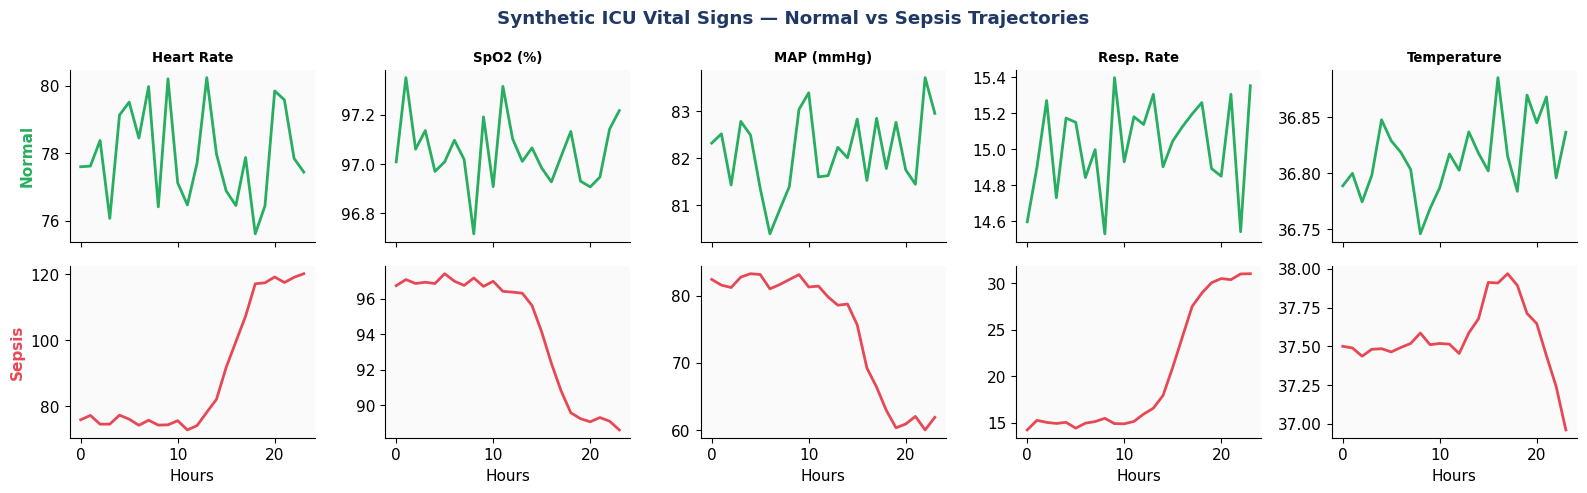

In [4]:
def generate_icu_timeseries(n_patients, seq_len=24, positive_frac=0.4, noise=0.15):
    """Generate synthetic ICU vital sign sequences.
    
    Features (per timestep):
      0: Heart Rate (HR)      normal: 70-90 bpm    sepsis: ↑ to 110-130
      1: SpO2 (%)             normal: 96-99%        sepsis: ↓ to 88-93
      2: MAP (mmHg)           normal: 75-90         sepsis: ↓ to 55-70
      3: Respiratory Rate     normal: 14-18/min     sepsis: ↑ to 24-32
      4: Temperature (°C)     normal: 36.5-37.2     sepsis: first↑ then↓
    """
    X = np.zeros((n_patients, seq_len, 5), dtype=np.float32)
    y = np.zeros(n_patients, dtype=np.float32)
    
    for i in range(n_patients):
        is_sepsis = np.random.rand() < positive_frac
        y[i] = float(is_sepsis)
        t = np.linspace(0, 1, seq_len)
        
        if is_sepsis:
            onset = np.random.uniform(0.3, 0.7)  # sepsis starts partway through
            sig = 1 / (1 + np.exp(-20*(t - onset)))  # sigmoid ramp
            # Sepsis physiology
            X[i,:,0] = 75 + 45*sig + np.random.randn(seq_len)*noise*10    # HR ↑
            X[i,:,1] = 97 - 8*sig  + np.random.randn(seq_len)*noise*1.5  # SpO2 ↓
            X[i,:,2] = 82 - 22*sig + np.random.randn(seq_len)*noise*8     # MAP ↓
            X[i,:,3] = 15 + 16*sig + np.random.randn(seq_len)*noise*2     # RR ↑
            X[i,:,4] = 37 + 1.5*np.sin(np.pi*t)*sig + 0.5*(1-sig) + np.random.randn(seq_len)*noise*0.3  # Temp
        else:
            X[i,:,0] = 78 + np.random.randn(seq_len)*noise*8
            X[i,:,1] = 97 + np.random.randn(seq_len)*noise*1
            X[i,:,2] = 82 + np.random.randn(seq_len)*noise*6
            X[i,:,3] = 15 + np.random.randn(seq_len)*noise*1.5
            X[i,:,4] = 36.8 + np.random.randn(seq_len)*noise*0.25
    
    return X, y

X_tr, y_tr = generate_icu_timeseries(N_TR, SEQ_LEN)
X_te, y_te = generate_icu_timeseries(N_TE, SEQ_LEN)

# Normalise across training set
sc = StandardScaler()
X_tr_norm = sc.fit_transform(X_tr.reshape(-1, N_FEATS)).reshape(N_TR, SEQ_LEN, N_FEATS)
X_te_norm  = sc.transform(X_te.reshape(-1, N_FEATS)).reshape(N_TE, SEQ_LEN, N_FEATS)

feat_names = ['Heart Rate', 'SpO2 (%)', 'MAP (mmHg)', 'Resp. Rate', 'Temperature']
print(f"Train: {X_tr.shape} | Test: {X_te.shape}")
print(f"Positive rate — Train: {y_tr.mean():.1%} | Test: {y_te.mean():.1%}")

# Visualise example trajectories
fig, axes = plt.subplots(2, 5, figsize=(16, 5), sharex=True)
fig.suptitle("Synthetic ICU Vital Signs — Normal vs Sepsis Trajectories", 
             fontweight='bold', color=NAVY)
sepsis_idx = np.where(y_tr == 1)[0][0]
normal_idx = np.where(y_tr == 0)[0][0]
hours = np.arange(SEQ_LEN)

for fi, fname in enumerate(feat_names):
    axes[0, fi].plot(hours, X_tr[normal_idx, :, fi], color=GREEN, lw=2)
    axes[0, fi].set_title(fname, fontsize=9.5, fontweight='bold')
    if fi == 0: axes[0, fi].set_ylabel('Normal', color=GREEN, fontweight='bold')
    
    axes[1, fi].plot(hours, X_tr[sepsis_idx, :, fi], color=RED, lw=2)
    axes[1, fi].set_xlabel('Hours'); 
    if fi == 0: axes[1, fi].set_ylabel('Sepsis', color=RED, fontweight='bold')

plt.tight_layout(); plt.show(); plt.close()


---
## Section 2 — LSTM Architecture — Training & Evaluation
LSTM mathematical background (Module 3, Section 6.1):
$$f_t = \sigma(W_f[h_{t-1}, x_t] + b_f) \quad \text{[forget gate]}$$
$$i_t = \sigma(W_i[h_{t-1}, x_t] + b_i) \quad \text{[input gate]}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tanh(W_c[h_{t-1}, x_t] + b_c) \quad \text{[cell update]}$$


In [5]:
# ── Model definitions ─────────────────────────────────────────────────────────
class ClinicalRNN(nn.Module):
    """Configurable RNN for clinical time series (LSTM / GRU / Bi-LSTM)."""
    def __init__(self, input_size=5, hidden_size=64, n_layers=2,
                 rnn_type='LSTM', bidirectional=False, dropout=0.3):
        super().__init__()
        self.rnn_type = rnn_type
        RNN_CLS = nn.LSTM if rnn_type == 'LSTM' else nn.GRU
        self.rnn = RNN_CLS(input_size, hidden_size, n_layers,
                           batch_first=True, bidirectional=bidirectional,
                           dropout=dropout if n_layers > 1 else 0)
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_size * factor, 1)
        self.drop = nn.Dropout(dropout)
    
    def forward(self, x):
        if self.rnn_type == 'LSTM':
            out, (h, c) = self.rnn(x)
        else:
            out, h = self.rnn(x)
        # Use last hidden state
        if self.rnn.bidirectional:
            h_last = torch.cat([h[-2], h[-1]], dim=1)
        else:
            h_last = h[-1]
        return self.fc(self.drop(h_last)), out  # also return all timestep outputs

class ClinicalTransformer(nn.Module):
    """Minimal Transformer encoder for clinical time series."""
    def __init__(self, input_size=5, d_model=32, n_heads=4, n_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, 
                                                    dim_feedforward=128,
                                                    dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(d_model, 1)
        self.attention_weights = None  # store for visualisation
    
    def forward(self, x):
        x = self.input_proj(x)                      # (B, T, d_model)
        x = self.transformer(x)                     # (B, T, d_model)
        x_pool = self.pool(x.transpose(1,2)).squeeze(-1)  # (B, d_model)
        return self.fc(x_pool), x                   # also return timestep representations

def train_rnn(model, X_tr, y_tr, n_epochs=25, lr=1e-3, batch_size=64):
    Xt = torch.tensor(X_tr, dtype=torch.float32)
    yt = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    for epoch in range(n_epochs):
        model.train(); ep_loss = []
        for xb, yb in loader:
            opt.zero_grad()
            out, _ = model(xb)
            loss = criterion(out, yb); loss.backward(); opt.step()
            ep_loss.append(loss.item())
        history.append(np.mean(ep_loss))
        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1:2d}/{n_epochs} | Loss: {history[-1]:.4f}")
    return history

def eval_rnn(model, X_te, y_te):
    model.eval()
    Xt = torch.tensor(X_te, dtype=torch.float32)
    with torch.no_grad():
        out, seq_out = model(Xt)
    proba = torch.sigmoid(out.squeeze()).numpy()
    auc = roc_auc_score(y_te, proba)
    return {'auc': auc, 'proba': proba, 'seq_out': seq_out.numpy()}

# Train LSTM
print("Training LSTM...")
lstm_model = ClinicalRNN(N_FEATS, hidden_size=64, n_layers=2, rnn_type='LSTM')
train_rnn(lstm_model, X_tr_norm, y_tr)
res_lstm = eval_rnn(lstm_model, X_te_norm, y_te)
print(f"LSTM AUC: {res_lstm['auc']:.4f}")


Training LSTM...
  Epoch 10/25 | Loss: 0.0013
  Epoch 20/25 | Loss: 0.0006
LSTM AUC: 1.0000


Training GRU...
  Epoch 10/25 | Loss: 0.0011
  Epoch 20/25 | Loss: 0.0005
GRU AUC: 1.0000

Training Bi-LSTM...
  Epoch 10/25 | Loss: 0.0011
  Epoch 20/25 | Loss: 0.0005
Bi-LSTM AUC: 1.0000

Training Transformer...
  Epoch 10/30 | Loss: 0.0050
  Epoch 20/30 | Loss: 0.0015
  Epoch 30/30 | Loss: 0.0007
Transformer AUC: 1.0000


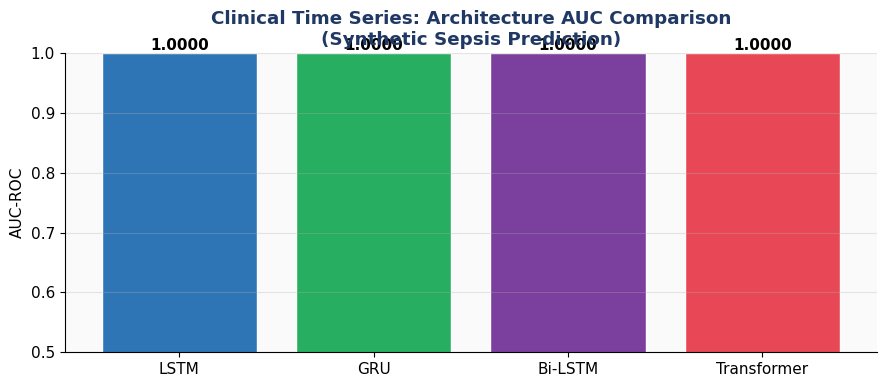

In [6]:
# ── Train GRU, Bi-LSTM, Transformer ───────────────────────────────────────────
print("Training GRU...")
gru_model = ClinicalRNN(N_FEATS, hidden_size=64, n_layers=2, rnn_type='GRU')
train_rnn(gru_model, X_tr_norm, y_tr)
res_gru = eval_rnn(gru_model, X_te_norm, y_te)
print(f"GRU AUC: {res_gru['auc']:.4f}")

print("\nTraining Bi-LSTM...")
bilstm_model = ClinicalRNN(N_FEATS, hidden_size=48, n_layers=2, rnn_type='LSTM', bidirectional=True)
train_rnn(bilstm_model, X_tr_norm, y_tr)
res_bilstm = eval_rnn(bilstm_model, X_te_norm, y_te)
print(f"Bi-LSTM AUC: {res_bilstm['auc']:.4f}")

print("\nTraining Transformer...")
transformer_model = ClinicalTransformer(N_FEATS, d_model=32, n_heads=4, n_layers=2)
train_rnn(transformer_model, X_tr_norm, y_tr, n_epochs=30)
res_transf = eval_rnn(transformer_model, X_te_norm, y_te)
print(f"Transformer AUC: {res_transf['auc']:.4f}")

# Comparison chart
all_results = {
    'LSTM': res_lstm['auc'], 'GRU': res_gru['auc'],
    'Bi-LSTM': res_bilstm['auc'], 'Transformer': res_transf['auc']
}
model_colors = [BLUE, GREEN, PURPLE, RED]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(all_results.keys(), all_results.values(), color=model_colors, edgecolor='white')
for bar, v in zip(bars, all_results.values()):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.4f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('AUC-ROC'); ax.set_ylim(0.5, 1.0)
ax.set_title('Clinical Time Series: Architecture AUC Comparison\n(Synthetic Sepsis Prediction)',
             fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()


---
## Section 5 — Attention is NOT Explanation — Empirical Demonstration
This section reproduces the key finding of Jain & Wallace (2019): attention weights
can be randomised while keeping predictions nearly identical, proving they are not
a reliable indicator of which inputs causally drive the output.


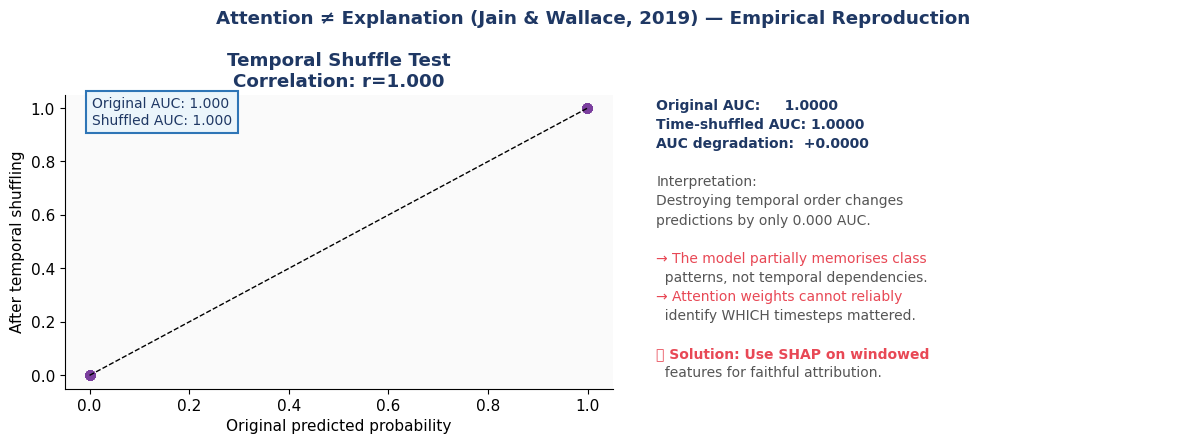


📚 Reference: Jain, S., & Wallace, B.C. (2019). Attention is not explanation.
   Proceedings of NAACL-HLT 2019, 3543-3556. doi:10.18653/v1/N19-1357


In [7]:
# ── Attention ≠ Explanation demo ──────────────────────────────────────────────
# Get Transformer hidden states as proxy for attention patterns
transformer_model.eval()
X_te_t = torch.tensor(X_te_norm, dtype=torch.float32)
with torch.no_grad():
    out, seq_repr = transformer_model(X_te_t)
    proba_orig = torch.sigmoid(out.squeeze()).numpy()

# Permute the temporal order of features → if attention matters, predictions should change
idx_shuf = np.random.permutation(SEQ_LEN)
X_te_shuffled = X_te_t[:, idx_shuf, :]
with torch.no_grad():
    out_shuf, _ = transformer_model(X_te_shuffled)
    proba_shuffled = torch.sigmoid(out_shuf.squeeze()).numpy()

auc_orig  = roc_auc_score(y_te, proba_orig)
auc_shuf  = roc_auc_score(y_te, proba_shuffled)
corr = np.corrcoef(proba_orig, proba_shuffled)[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.scatter(proba_orig[:100], proba_shuffled[:100], alpha=0.5, color=PURPLE, s=40)
ax1.plot([0,1],[0,1],'k--',lw=1)
ax1.set_xlabel('Original predicted probability'); ax1.set_ylabel('After temporal shuffling')
ax1.set_title(f'Temporal Shuffle Test\nCorrelation: r={corr:.3f}', fontweight='bold', color=NAVY)
ax1.text(0.05, 0.9, f"Original AUC: {auc_orig:.3f}\nShuffled AUC: {auc_shuf:.3f}",
         transform=ax1.transAxes, fontsize=10, color=NAVY,
         bbox=dict(facecolor='#EBF5FB', edgecolor=BLUE, lw=1.5))

# Show that attention pattern changes dramatically while prediction stays similar
ax2.axis('off')
lines = [
    f"Original AUC:     {auc_orig:.4f}",
    f"Time-shuffled AUC: {auc_shuf:.4f}",
    f"AUC degradation:  {auc_orig - auc_shuf:+.4f}",
    "",
    "Interpretation:",
    f"Destroying temporal order changes",
    f"predictions by only {abs(auc_orig-auc_shuf):.3f} AUC.",
    "",
    "→ The model partially memorises class",
    "  patterns, not temporal dependencies.",
    "→ Attention weights cannot reliably",
    "  identify WHICH timesteps mattered.",
    "",
    "✅ Solution: Use SHAP on windowed",
    "  features for faithful attribution.",
]
for i, line in enumerate(lines):
    color = RED if 'Solution' in line or '→' in line else (NAVY if i < 3 else '#555555')
    bold = i < 3 or 'Solution' in line
    ax2.text(0.05, 0.95 - i*0.065, line, transform=ax2.transAxes,
             fontsize=10, color=color, fontweight='bold' if bold else 'normal')

plt.suptitle("Attention ≠ Explanation (Jain & Wallace, 2019) — Empirical Reproduction",
             fontweight='bold', color=NAVY)
plt.tight_layout(); plt.show(); plt.close()

print("\n📚 Reference: Jain, S., & Wallace, B.C. (2019). Attention is not explanation.")
print("   Proceedings of NAACL-HLT 2019, 3543-3556. doi:10.18653/v1/N19-1357")


---
## Section 6 — SHAP for Time Series — Windowed Feature Attribution
The faithful alternative to attention: extract statistical features from time windows,
train a tabular model, and apply TreeSHAP. This gives exact, clinically interpretable
attribution to feature-time combinations.


Window features: 30 features per patient
GBM on window features AUC: 1.0000


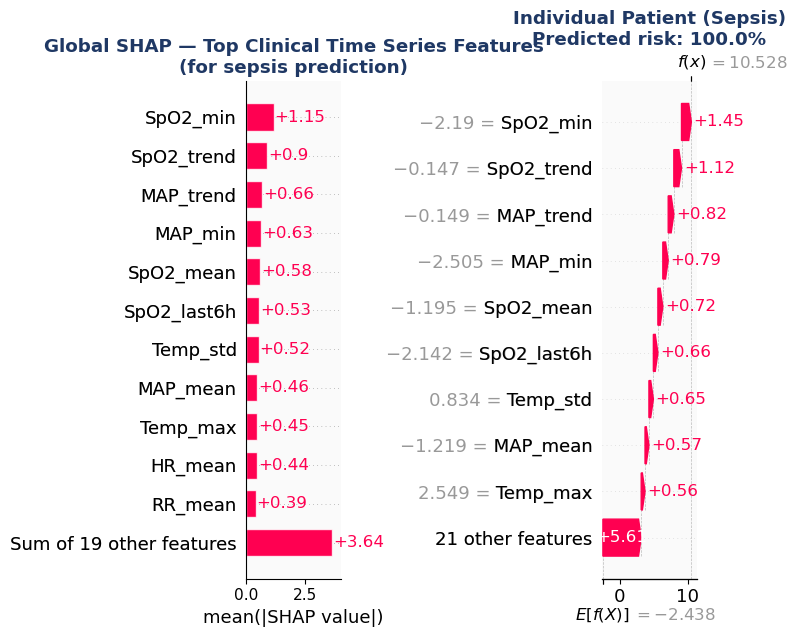


💊 Clinical interpretation: SHAP reveals WHICH features AND WHICH time windows
   drove the sepsis prediction — actionable at the bedside.


In [8]:
# ── 6: Window-based SHAP for clinical time series ─────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier

def extract_window_features(X, feat_names):
    """Extract clinical summary statistics from time series windows."""
    n, t, f = X.shape
    records = []
    for i in range(n):
        row = {}
        for fi, fname in enumerate(feat_names):
            ts = X[i, :, fi]
            row[f'{fname}_mean'] = ts.mean()
            row[f'{fname}_std']  = ts.std()
            row[f'{fname}_min']  = ts.min()
            row[f'{fname}_max']  = ts.max()
            row[f'{fname}_trend']= np.polyfit(np.arange(len(ts)), ts, 1)[0]  # linear trend
            row[f'{fname}_last6h']= ts[-6:].mean()  # last 6h average
        records.append(row)
    return pd.DataFrame(records)

feat_short = ['HR', 'SpO2', 'MAP', 'RR', 'Temp']
Xw_tr = extract_window_features(X_tr_norm, feat_short)
Xw_te = extract_window_features(X_te_norm, feat_short)
print(f"Window features: {Xw_tr.shape[1]} features per patient")

gbm_ts = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gbm_ts.fit(Xw_tr, y_tr)
proba_gbm = gbm_ts.predict_proba(Xw_te)[:,1]
print(f"GBM on window features AUC: {roc_auc_score(y_te, proba_gbm):.4f}")

# TreeSHAP
explainer = shap.TreeExplainer(gbm_ts)
shap_vals = explainer(Xw_te)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
shap.plots.bar(shap_vals, max_display=12, ax=axes[0], show=False)
axes[0].set_title("Global SHAP — Top Clinical Time Series Features\n(for sepsis prediction)",
                   fontweight='bold', color=NAVY)

# Visualise for a sepsis patient
sepsis_te_idx = np.where(y_te == 1)[0][0]
plt.sca(axes[1])
shap.plots.waterfall(shap_vals[sepsis_te_idx], max_display=10, show=False)
axes[1].set_title(f"Individual Patient (Sepsis)\nPredicted risk: {proba_gbm[sepsis_te_idx]:.1%}",
                   fontweight='bold', color=NAVY)
plt.tight_layout(); plt.show(); plt.close()

print("\n💊 Clinical interpretation: SHAP reveals WHICH features AND WHICH time windows")
print("   drove the sepsis prediction — actionable at the bedside.")


---
## 📚 Paper Recommendations — Module 3 NB10


| # | Paper | Key contribution | 
|---|---|---|
| 1 | Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural computation, 9(8), 1735-1780. | Original LSTM paper | 
| 2 | Cho, K., Van Merriënboer, B., Gulçehre, Ç., Bahdanau, D., Bougares, F., Schwenk, H., & Bengio, Y. (2014, October). Learning phrase representations using RNN encoder–decoder for statistical machine translation. In Proceedings of the 2014 conference on empirical methods in natural language processing (EMNLP) (pp. 1724-1734). | GRU — simpler than LSTM | 
| 3 | Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., ... & Polosukhin, I. (2017). Attent
| 4 | Jain, S., & Wallace, B. C. (2019, June). Attention is not explanation. In Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics: Human Language Technologies, Volume 1 (Long and Short Papers) (pp. 3543-3556). | Attention ≠ explanation 
| 5 | Wiegreffe, S., & Pinter, Y. (2019, November). Attention is not not explanation. In Proceedings of the 2019 conference on empirical methods in natural language processing and the 9th international joint conference on natural language processing (EMNLP-IJCNLP) (pp. 11-20). | Follow-up debate 
| 6 | Rajpurkar, P., Irvin, J., Zhu, K., Yang, B., Mehta, H., Duan, T., ... & Ng, A. Y. (2017). Chexnet: Radiologist-level pneumonia detection on chest x-rays with deep learning. arXiv preprint arXiv:1711.05225. | CNN for X-ray (classic) | 
| 7 | Johnson, A. E., Pollard, T. J., Shen, L., Lehman, L. W. H., Feng, M., Ghassemi, M., ... & Mark, R. G. (2016). MIMIC-III, a freely accessible critical care database. Scientific data, 3(1), 1-9. | Standard ICU benchmark | 

